<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%204/L1_Convolution_and_Hyperparameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=cUBWTR3-bCc) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%204/NPTEL_Jul24_DL4CV_W04_P01.pdf)

In [ ]:
# Week 4, Lecture 1: CNN's Part 1
from IPython.display import HTML, display

VIDEO_ID = "cUBWTR3-bCc"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

Watch on YouTube

# Week 4, Lecture 1: The Convolution Operation and Its (Hyper)Parameters

Deep Learning for Computer Vision (NPTEL)

What you will learn:
- What the convolution operation is: a way of combining two signals into a third.
- How convolution works in 1D, then 2D (grayscale), then 3D (color / RGB).
- The important clarification that deep learning "convolution" is really cross-correlation (no kernel flip).
- The convolution hyperparameters: input size, filter spatial extent $F$, stride $S$, padding $P$, and number of filters $K$.
- How the output size is computed, built up step by step, ending with $W_2 = \frac{W_1 - F + 2P}{S} + 1$.
- Why the output depth equals the number of filters ($D_2 = K$).

Prerequisites: basic Python, numpy, and the idea of a neural network.

How to use this notebook:
- Run the cells top to bottom.
- On Google Colab the interactive sliders and dropdowns work automatically. Just run each widget cell and move the controls.
- All tensors and images are tiny, so the whole notebook runs in about one to two minutes.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
from ipywidgets import interact, IntSlider, Dropdown

# Reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Works on both CPU and GPU with no edits
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch version:', torch.__version__)
print('Device:', device)

PyTorch version: 2.8.0
Device: cpu


## What is convolution? Start in 1D

- Convolution is a mathematical way of combining two signals to form a third signal.
- In 1D we slide a 1D filter (kernel) across a 1D input and, at each step, multiply the overlapping values and add them up.
- The output at each position is a single number: the dot product of the kernel with the window it currently covers.
- With a length $N$ signal and a length $F$ kernel (no padding, stride 1) the output has length $N - F + 1$.
- Progression for this lecture: 1D signal, then 2D image, then 3D color volume.

signal x : [0. 0. 1. 1. 1. 0. 0. 2. 2. 0. 0. 1. 0. 0.]
kernel w : [ 1.  0. -1.]
output y : [-1. -1.  0.  1.  1. -2. -2.  2.  2. -1.  0.  1.]
lengths  : len(x)=14, F=3, len(y)=len(x)-F+1=12
matches torch F.conv1d: True


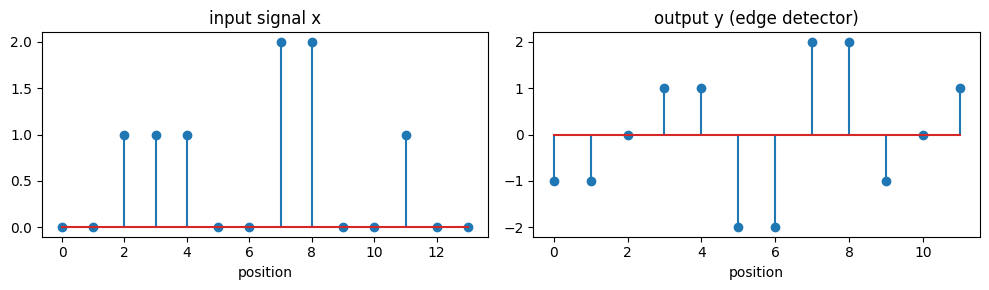

In [2]:
# A small 1D signal and a small kernel. We slide the kernel across the signal and,
# at each position, compute the dot product of the kernel with the window it covers.
# This "no flip" version is cross-correlation, which is exactly what deep learning
# libraries call "convolution".

x1d = np.array([0, 0, 1, 1, 1, 0, 0, 2, 2, 0, 0, 1, 0, 0], dtype=float)
w1d = np.array([1, 0, -1], dtype=float)   # a simple edge / difference detector

def conv1d_naive(x, w):
    F_len = len(w)
    out_len = len(x) - F_len + 1
    y = np.zeros(out_len)
    for i in range(out_len):
        window = x[i:i + F_len]
        y[i] = np.sum(window * w)          # multiply and add (a dot product)
    return y

y1d = conv1d_naive(x1d, w1d)
print('signal x :', x1d)
print('kernel w :', w1d)
print('output y :', y1d)
print('lengths  : len(x)=%d, F=%d, len(y)=len(x)-F+1=%d' % (len(x1d), len(w1d), len(y1d)))

# Peel the onion: check against PyTorch conv1d (which also does cross-correlation)
xt = torch.tensor(x1d, dtype=torch.float32).view(1, 1, -1)
wt = torch.tensor(w1d, dtype=torch.float32).view(1, 1, -1)
y_torch = F.conv1d(xt, wt).view(-1).numpy()
assert np.allclose(y1d, y_torch, atol=1e-5)
print('matches torch F.conv1d:', np.allclose(y1d, y_torch, atol=1e-5))

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].stem(range(len(x1d)), x1d); ax[0].set_title('input signal x'); ax[0].set_xlabel('position')
ax[1].stem(range(len(y1d)), y1d); ax[1].set_title('output y (edge detector)'); ax[1].set_xlabel('position')
plt.tight_layout(); plt.show()

### Interactive: slide the 1D kernel

Move the position slider to place the kernel over different windows of the signal, and use the dropdown to switch the kernel. The orange band is the current window; the title shows the single output value (the dot product) it produces.

In [3]:
# Interactive 1D convolution. All kernels have length 3 so the position range is fixed.
kernels_1d = {
    'edge [1,0,-1]':        np.array([1, 0, -1], dtype=float),
    'moving average':       np.array([1/3, 1/3, 1/3], dtype=float),
    'sharpen [-1,3,-1]':    np.array([-1, 3, -1], dtype=float),
    'smooth [.25,.5,.25]':  np.array([0.25, 0.5, 0.25], dtype=float),
}

def show_conv1d(position=0, kernel='edge [1,0,-1]'):
    w = kernels_1d[kernel]
    F_len = len(w)
    y = conv1d_naive(x1d, w)
    pos = min(position, len(x1d) - F_len)
    val = np.sum(x1d[pos:pos + F_len] * w)

    fig, ax = plt.subplots(2, 1, figsize=(9, 5))
    # top: signal with the current window highlighted
    ax[0].stem(range(len(x1d)), x1d)
    ax[0].axvspan(pos - 0.4, pos + F_len - 0.6, color='orange', alpha=0.3)
    ax[0].set_title('signal x   |   window at pos %d   |   dot product = %.2f' % (pos, val))
    ax[0].set_xlim(-0.5, len(x1d) - 0.5)
    # bottom: output so far with the value just computed marked in red
    ax[1].stem(range(len(y)), y)
    ax[1].plot(pos, y[pos], 'ro', ms=10)
    ax[1].set_title('output y   (red dot is the value computed from the window above)')
    ax[1].set_xlim(-0.5, len(x1d) - 0.5)
    plt.tight_layout(); plt.show()

interact(show_conv1d,
         position=IntSlider(min=0, max=len(x1d) - 3, step=1, value=3),
         kernel=Dropdown(options=list(kernels_1d.keys()), value='edge [1,0,-1]'));

## 2D convolution (grayscale images)

- For a 2D image $X$ and a $k \times k$ filter $W$, the slides write convolution as
  $Y(i,j) = \sum_u \sum_v W(u,v)\, X(i-u,\, j-v)$.
- A centered form lets the kernel sit on the pixel of interest (the sums run over the half width of the kernel), which is why odd kernel sizes are convenient.
- In code we slide the kernel over every valid position and take the sum of the elementwise product (a dot product) of the kernel with the image patch it covers.
- We implement cross-correlation (no flip), which is what PyTorch computes; we revisit the flip in the next section.
- Classic fixed kernels do useful things: blur, sharpen, and detect edges (Sobel, Laplacian).

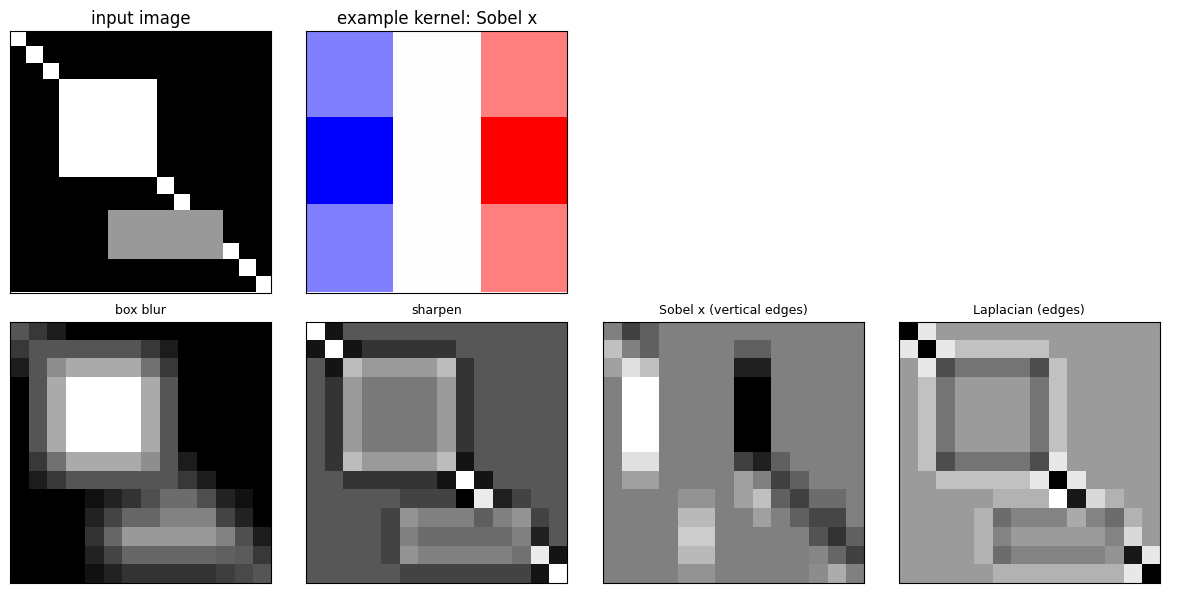

In [4]:
# Build a small synthetic grayscale image (no external files needed).
# It contains a filled square, a diagonal line, and a rectangle so edges are easy to see.
img = np.zeros((16, 16), dtype=float)
img[3:9, 3:9] = 1.0                 # a bright square
for d in range(16):
    img[d, d] = 1.0                 # a diagonal line
img[11:14, 6:13] = 0.6             # a rectangle block

# Classic 3x3 kernels
kernels_2d = {
    'identity':                    np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]], float),
    'box blur':                    np.ones((3, 3), float) / 9.0,
    'sharpen':                     np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], float),
    'Sobel x (vertical edges)':    np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], float),
    'Sobel y (horizontal edges)':  np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], float),
    'Laplacian (edges)':           np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], float),
}

def conv2d_naive(X, W):
    H, Wd = X.shape
    Fh, Fw = W.shape
    oh, ow = H - Fh + 1, Wd - Fw + 1
    Y = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            Y[i, j] = np.sum(X[i:i + Fh, j:j + Fw] * W)   # cross-correlation (no flip)
    return Y

# Show input, an example kernel, and several filtered outputs
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes[0, 0].imshow(img, cmap='gray');                        axes[0, 0].set_title('input image')
axes[0, 1].imshow(kernels_2d['Sobel x (vertical edges)'], cmap='bwr'); axes[0, 1].set_title('example kernel: Sobel x')
axes[0, 2].axis('off'); axes[0, 3].axis('off')
show_names = ['box blur', 'sharpen', 'Sobel x (vertical edges)', 'Laplacian (edges)']
for a, nm in zip(axes[1], show_names):
    a.imshow(conv2d_naive(img, kernels_2d[nm]), cmap='gray'); a.set_title(nm, fontsize=9)
for a in axes.ravel():
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

In [5]:
# Peel the onion: our from-scratch conv2d_naive should match PyTorch F.conv2d exactly.
# PyTorch conv layers compute cross-correlation (no kernel flip), which is what
# conv2d_naive does, so they agree directly.
Xt = torch.tensor(img, dtype=torch.float32).view(1, 1, 16, 16)
for nm, W in kernels_2d.items():
    ours = conv2d_naive(img, W)
    Wt = torch.tensor(W, dtype=torch.float32).view(1, 1, 3, 3)
    theirs = F.conv2d(Xt, Wt)[0, 0].numpy()
    ok = np.allclose(ours, theirs, atol=1e-5)
    print('%-28s match=%s  output shape=%s' % (nm, ok, ours.shape))
    assert ok
print('All kernels match F.conv2d.')

identity                     match=True  output shape=(14, 14)
box blur                     match=True  output shape=(14, 14)
sharpen                      match=True  output shape=(14, 14)
Sobel x (vertical edges)     match=True  output shape=(14, 14)
Sobel y (horizontal edges)   match=True  output shape=(14, 14)
Laplacian (edges)            match=True  output shape=(14, 14)
All kernels match F.conv2d.


### Interactive: pick a 2D kernel

Choose a kernel from the dropdown and watch the filtered image update. Notice how Sobel x lights up vertical edges, Sobel y lights up horizontal edges, and the Laplacian highlights all edges.

In [6]:
def show_conv2d(kernel='Sobel x (vertical edges)'):
    W = kernels_2d[kernel]
    out = conv2d_naive(img, W)
    fig, ax = plt.subplots(1, 3, figsize=(11, 4))
    ax[0].imshow(img, cmap='gray');  ax[0].set_title('input (16x16)')
    ax[1].imshow(W, cmap='bwr');     ax[1].set_title('kernel 3x3: ' + kernel)
    for (i, j), v in np.ndenumerate(W):
        ax[1].text(j, i, '%.2f' % v, ha='center', va='center', fontsize=8)
    ax[2].imshow(out, cmap='gray');  ax[2].set_title('output (14x14)')
    for a in ax:
        a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()

interact(show_conv2d, kernel=Dropdown(options=list(kernels_2d.keys()), value='Sobel x (vertical edges)'));

## Cross-correlation vs true convolution

- The slides define convolution with a kernel flip: $Y(i,j) = \sum_u \sum_v W(u,v)\, X(i-u,\, j-v)$.
- Deep learning libraries (PyTorch included) skip the flip and compute cross-correlation: $Y(i,j) = \sum_u \sum_v W(u,v)\, X(i+u,\, j+v)$.
- Because the kernel weights are learned anyway, the missing flip does not matter for learning; it only matters when you use a fixed, known kernel.
- Key relationship: true convolution with $W$ equals cross-correlation with the 180 degree flipped $W$.

In [7]:
# Deep learning "convolution" is cross-correlation (no flip). True mathematical
# convolution first rotates the kernel by 180 degrees. Relationship:
#   true_convolution(X, W) == cross_correlation(X, flip180(W))

W = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]], float)   # asymmetric so the flip matters
W_flip = np.flip(np.flip(W, 0), 1).copy()                 # rotate 180 degrees (copy for a positive-stride array)

cc = conv2d_naive(img, W)          # cross-correlation (what PyTorch does)
tc = conv2d_naive(img, W_flip)     # true convolution = cross-correlation with the flipped kernel

print('original kernel:\n', W)
print('flipped 180 kernel:\n', W_flip)
print('cross-correlation(X,W) equals true convolution(X,W)?', np.allclose(cc, tc),
      '  (they differ because the kernel is asymmetric)')

# Confirm with PyTorch: F.conv2d is cross-correlation, so to get TRUE convolution
# we must hand it the flipped kernel.
Xt = torch.tensor(img, dtype=torch.float32).view(1, 1, 16, 16)
theirs_cc = F.conv2d(Xt, torch.tensor(W, dtype=torch.float32).view(1, 1, 3, 3))[0, 0].numpy()
true_conv = F.conv2d(Xt, torch.tensor(W_flip, dtype=torch.float32).view(1, 1, 3, 3))[0, 0].numpy()
assert np.allclose(cc, theirs_cc, atol=1e-5)
assert np.allclose(tc, true_conv, atol=1e-5)
print('Verified: F.conv2d(X, W) is cross-correlation; F.conv2d(X, flip(W)) is true convolution.')

original kernel:
 [[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]
flipped 180 kernel:
 [[9. 8. 7.]
 [6. 5. 4.]
 [3. 2. 1.]]
cross-correlation(X,W) equals true convolution(X,W)? False   (they differ because the kernel is asymmetric)
Verified: F.conv2d(X, W) is cross-correlation; F.conv2d(X, flip(W)) is true convolution.


## Moving to 3D: color (RGB) images

- A color image is 3D: shape $D_1 \times H \times W$ with $D_1 = 3$ channels (R, G, B).
- A 3D filter is a volume whose depth always equals the input depth ($D_1$).
- Because the filter already spans the full depth, it slides only along height and width. This is a 2D convolution on a 3D input.
- Each filter collapses the depth and produces a single 2D feature map (the output has no depth of its own).
- Applying $K$ filters produces $K$ feature maps, so the output depth is $D_2 = K$.

input volume shape : (3, 12, 12) (C, H, W)
filter volume shape: (3, 3, 3) (C, F, F)
one feature map    : (10, 10) (2D, depth collapsed)
K = 4 filters -> output shape (4, 10, 10) (K, H2, W2), so D2 = K
matches F.conv2d: True


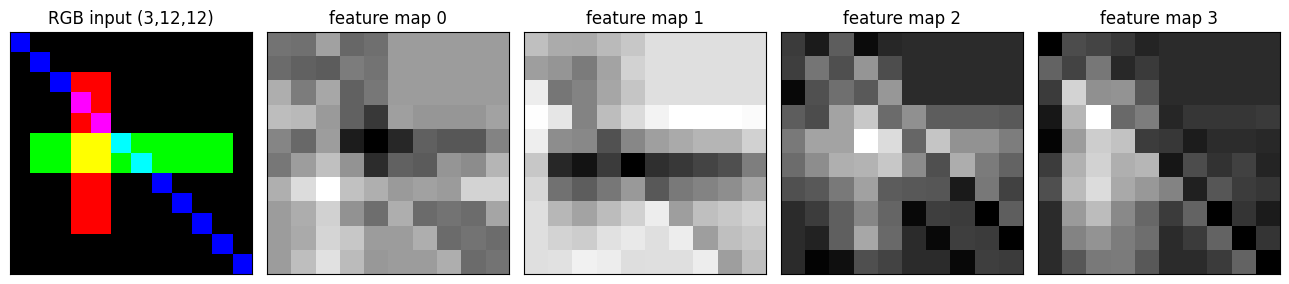

In [8]:
# A small color image has shape (3, H, W): channels R, G, B (depth D1 = 3).
# A 3D filter has shape (3, F, F): its depth matches the input depth.
C, H, Wd = 3, 12, 12
rgb = np.zeros((C, H, Wd), dtype=float)
rgb[0, 2:10, 3:5] = 1.0     # red: a vertical bar
rgb[1, 5:7, 1:11] = 1.0     # green: a horizontal bar
for d in range(12):
    rgb[2, d, d] = 1.0       # blue: a diagonal

def conv_volume(X, W):
    # X: (C, H, W),  W: (C, F, F)  ->  a single 2D map (summed over ALL channels)
    C, H, Wd = X.shape
    Ff = W.shape[1]
    oh, ow = H - Ff + 1, Wd - Ff + 1
    Y = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            Y[i, j] = np.sum(X[:, i:i + Ff, j:j + Ff] * W)   # sum over depth too
    return Y

# One filter -> one 2D feature map (depth is gone)
F3 = 3
filt = np.random.randn(C, F3, F3)
one_map = conv_volume(rgb, filt)
print('input volume shape :', rgb.shape, '(C, H, W)')
print('filter volume shape:', filt.shape, '(C, F, F)')
print('one feature map    :', one_map.shape, '(2D, depth collapsed)')

# K filters -> K feature maps stacked -> output depth D2 = K
K = 4
filters = np.random.randn(K, C, F3, F3)
maps = np.stack([conv_volume(rgb, filters[k]) for k in range(K)], axis=0)
print('K =', K, 'filters -> output shape', maps.shape, '(K, H2, W2), so D2 = K')

# Peel the onion: check against PyTorch F.conv2d with weight shape (K, C, F, F)
Xt = torch.tensor(rgb, dtype=torch.float32).unsqueeze(0)     # (1, 3, 12, 12)
Wt = torch.tensor(filters, dtype=torch.float32)              # (4, 3, 3, 3)
maps_torch = F.conv2d(Xt, Wt)[0].numpy()
assert np.allclose(maps, maps_torch, atol=1e-5)
print('matches F.conv2d:', np.allclose(maps, maps_torch, atol=1e-5))

# Visualize the RGB input and the K feature maps
fig, ax = plt.subplots(1, 5, figsize=(13, 3))
ax[0].imshow(np.transpose(rgb, (1, 2, 0))); ax[0].set_title('RGB input (3,12,12)')
for k in range(K):
    ax[k + 1].imshow(maps[k], cmap='gray'); ax[k + 1].set_title('feature map %d' % k)
for a in ax:
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## Convolution hyperparameters and the output-size formula

A convolution layer is described by a few numbers:
- Input volume: $W_1 \times H_1 \times D_1$ (width, height, depth).
- Filter spatial extent $F$ (each filter has depth $D_1$, equal to the input depth).
- Stride $S$: the step size as the filter slides.
- Padding $P$: rings of zeros added around the input.
- Number of filters $K$.
- Output volume: $W_2 \times H_2 \times D_2$.

The output width $W_2$ is built up in stages, exactly as in the slides:
1. No padding, stride 1: the kernel cannot sit on the corners without crossing the boundary, so the output shrinks: $W_2 = W_1 - F + 1$. A bigger kernel shrinks it more.
2. Add zero padding $P$ so the kernel can reach the corners again: $W_2 = W_1 - F + 2P + 1$.
3. Add stride $S$ (apply the filter every $S$ pixels): $W_2 = \frac{W_1 - F + 2P}{S} + 1$.

The same formula holds for height: $H_2 = \frac{H_1 - F + 2P}{S} + 1$.

If $\frac{W_1 - F + 2P}{S}$ is not a whole number the setting is invalid (PyTorch floors it). Use the playground below to build intuition.

### The output-size playground

Move the sliders and watch $W_2 = \frac{W_1 - F + 2P}{S} + 1$ change (the input is shown square, so $H_2 = W_2$).
- Blue cells are the input; gray cells are the zero padding ring.
- The green square is one kernel footprint (size $F \times F$).
- Red dots mark the center of every position where the kernel lands under the current stride $S$. The number of red dots along one side equals $W_2$.
- If the formula does not give a whole number, the title turns red to flag an invalid setting.

In [9]:
def draw_playground(W1=6, F=3, P=1, S=1):
    Wp = W1 + 2 * P                       # padded side length
    numer = W1 - F + 2 * P
    valid = (numer >= 0) and (numer % S == 0)
    W2 = (numer // S + 1) if numer >= 0 else 0

    fig, ax = plt.subplots(figsize=(6, 6))
    # draw every cell of the padded input
    for r in range(Wp):
        for c in range(Wp):
            is_pad = (r < P) or (c < P) or (r >= P + W1) or (c >= P + W1)
            color = '#e0e0e0' if is_pad else '#bcd8f7'
            ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=color, edgecolor='white', lw=1.5))
    # draw the stride sampling: a dot at the center of every kernel position
    if valid and W2 > 0:
        for oy in range(W2):
            for ox in range(W2):
                ax.plot(ox * S + F / 2.0, oy * S + F / 2.0, 'o', color='#d62728', ms=5)
        # one kernel footprint (top-left position) to show the filter size F
        ax.add_patch(plt.Rectangle((0, 0), F, F, fill=False, edgecolor='#2ca02c', lw=2.5))

    ax.set_xlim(-0.3, Wp + 0.3); ax.set_ylim(-0.3, Wp + 0.3)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    if valid:
        ax.set_title('W1=%d, F=%d, P=%d, S=%d\nW2 = (%d - %d + 2*%d)/%d + 1 = %d   (output %dx%d)'
                     % (W1, F, P, S, W1, F, P, S, W2, W2, W2), color='black')
    else:
        reason = 'negative size (kernel bigger than padded input)' if numer < 0 else 'not divisible by stride'
        ax.set_title('W1=%d, F=%d, P=%d, S=%d\nINVALID: (W1 - F + 2P)/S = %d/%d is %s'
                     % (W1, F, P, S, numer, S, reason), color='#d62728')
    plt.show()

interact(draw_playground,
         W1=IntSlider(min=3, max=12, step=1, value=6),
         F=IntSlider(min=1, max=7, step=2, value=3),
         P=IntSlider(min=0, max=3, step=1, value=1),
         S=IntSlider(min=1, max=3, step=1, value=1));

## Depth of the output: number of filters

- Each filter spans the full input depth and produces exactly one 2D feature map.
- Using $K$ filters gives $K$ such 2D maps.
- Stack them to get an output volume of shape $W_2 \times H_2 \times K$.
- Therefore the output depth is $D_2 = K$. The depth is your choice (how many filters), not something forced by the input.

Move the slider below to see the output depth grow as you add filters.

In [10]:
def draw_depth(K=6):
    base = 4.0
    fig, ax = plt.subplots(figsize=(7, 4))
    # draw K offset squares to suggest a stack of K feature maps (a volume of depth K)
    for k in range(K):
        x0, y0 = k * 0.35, k * 0.25
        col = plt.cm.viridis(k / max(K - 1, 1))
        ax.add_patch(plt.Rectangle((x0, y0), base, base, facecolor=col, edgecolor='black', alpha=0.9))
    ax.set_xlim(-0.5, base + K * 0.35 + 0.5)
    ax.set_ylim(-0.5, base + K * 0.25 + 0.5)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title('K = %d filters   ->   output depth D2 = %d\n(each filter yields one 2D feature map)' % (K, K))
    plt.show()

interact(draw_depth, K=IntSlider(min=1, max=8, step=1, value=6));

## Quick exercise (from the slide)

Work out the output volume for:
- Input $32 \times 32 \times 3$
- Six filters of $5 \times 5 \times 3$
- Stride $S = 1$, padding $P = 0$

Predict the answer, then run the cell to check it with the formula and with a real `nn.Conv2d`.

In [11]:
# Slide exercise: input 32 x 32 x 3, six filters of 5 x 5 x 3, stride 1, pad 0.
W1 = H1 = 32
D1 = 3
Fs = 5
S = 1
P = 0
K = 6

W2 = (W1 - Fs + 2 * P) // S + 1
H2 = (H1 - Fs + 2 * P) // S + 1
D2 = K
print('By formula: W2 = (%d - %d + 2*%d)/%d + 1 = %d' % (W1, Fs, P, S, W2))
print('Output volume by formula (W2, H2, D2):', (W2, H2, D2))

# Verify with a real convolution layer
x = torch.randn(1, D1, H1, W1)
conv = nn.Conv2d(in_channels=D1, out_channels=K, kernel_size=Fs, stride=S, padding=P)
out = conv(x)
print('nn.Conv2d output shape:', tuple(out.shape), '= (batch, D2, H2, W2)')

assert tuple(out.shape) == (1, D2, H2, W2)
assert (W2, H2, D2) == (28, 28, 6)
print('Confirmed: 32x32x3 with six 5x5x3 filters, stride 1, pad 0  ->  28x28x6.')

By formula: W2 = (32 - 5 + 2*0)/1 + 1 = 28
Output volume by formula (W2, H2, D2): (28, 28, 6)
nn.Conv2d output shape: (1, 6, 28, 28) = (batch, D2, H2, W2)
Confirmed: 32x32x3 with six 5x5x3 filters, stride 1, pad 0  ->  28x28x6.


## Key takeaways

- Convolution combines two signals into a third; in 2D we slide a kernel over an image and take dot products.
- Progression: 1D signal, 2D grayscale image, 3D color volume. A filter's depth always matches the input depth, so a color convolution is a 2D slide over a 3D input.
- Each filter yields one 2D feature map; $K$ filters give an output depth $D_2 = K$.
- Deep learning "convolution" is cross-correlation (no kernel flip); true convolution uses the 180 degree flipped kernel.
- Hyperparameters: input $W_1 \times H_1 \times D_1$, filter extent $F$, stride $S$, padding $P$, number of filters $K$.
- Output size, built up in stages: $W_1 - F + 1$, then $W_1 - F + 2P + 1$, then $W_2 = \frac{W_1 - F + 2P}{S} + 1$ (and the same for $H_2$).
- Corners cannot be reached without padding, so the output shrinks; a bigger kernel shrinks it more; padding can restore the size and stride reduces it.

## Try it yourself
- In the output-size playground, find settings that keep the output the same size as the input (hint: $F = 3, P = 1, S = 1$).
- Set the stride to 2 in the playground and watch the red dots thin out and $W_2$ drop.
- Switch the 2D kernel dropdown to Sobel y and compare it with Sobel x on the diagonal line.
- In the worked exercise, change $K$ to 16 and confirm the output depth becomes 16.
- Add padding $P = 2$ to the $5 \times 5$ exercise and predict the new output size before running.